# Práctica4: Clasificación de Ropa con Fashion MNIST
**Consigna:** El objetivo de este ejercicio es diseñar, entrenar y evaluar una red neuronal profunda (MLP) capaz de clasificar imágenes de 28x28 píxeles en 10 categorías de vestimenta. Deberás completar las secciones de código indicadas para que el modelo logre una precisión aceptable en el set de prueba.

## 1. Carga de Datos y Preprocesamiento
El primer paso es normalizar las imágenes. Como las redes neuronales son calculadoras de promedios ponderados, es vital que las entradas estén en la misma escala (generalmente entre 0 y 1) para evitar que magnitudes grandes dominen el aprendizaje.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Cargamos el dataset de ropa
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Etiquetas de las 10 categorías
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalizamos los píxeles al rango [0, 1] dividiendo por 255.0
train_images = train_images / 255.0
test_images = test_images / 255.0

Al dividir por 255, transformamos cada píxel en una probabilidad de intensidad. Esto evita que los valores grandes dominen el cálculo y ayuda a que el "descenso de gradiente" sea más estable.

## 2. Definición de la Arquitectura (MLP)
Configurar las capas de la red. Recordar que la Capa de Entrada debe **"aplanar"** la matriz de 28x28. En las Capas Ocultas, utilizamos la función **ReLU** por su eficiencia para transmitir señales positivas . Finalmente, la Capa de Salida debe tener 10 neuronas (una por cada prenda) y usar **Softmax** para entregar una distribución de probabilidad que sume 1 .

In [ ]:
model = models.Sequential([
    # Capa de Entrada: "Aplana" la matriz de 28x28 a un vector de 784 píxeles
    layers.Flatten(input_shape=(28, 28)),

    # Capa Oculta 1: 128 neuronas con ReLU para detectar formas básicas
    layers.Dense(128, activation='relu'),

    # Capa Oculta 2: 64 neuronas con ReLU para patrones más específicos
    layers.Dense(64, activation='relu'),

    # Capa de Salida: 10 neuronas (una por categoría) con Softmax
    layers.Dense(10, activation='softmax')
])

### Flatten:
Convierte la imagen 2D en una fila de datos para que la red pueda procesarla.
### ReLU:
 Es el estándar de la industria. Deja pasar las señales positivas y bloquea las negativas, evitando el "desvanecimiento del gradiente".
### Softmax:
Es vital en clasificación multiclase. Hace que las 10 salidas sumen exactamente 1 (o 100%), entregando una distribución de probabilidad para cada prenda

## 3. Compilación y Entrenamiento
Para que la red aprenda, aplicamos el algoritmo de Backpropagation. Configuraremos el optimizador para ajustar los pesos y una función de pérdida que mida la discrepancia entre la predicción y la realidad

In [ ]:
model.compile(
    optimizer='adam', #adam Un optimizador avanzado que ajusta la tasa de aprendizaje automáticamente para cada peso.
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Configuramos Early Stopping para monitorear el error de validación es como un "freno de mano"
#automático para no sobreentrenar el modelo
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitorea si la red está aprendiendo o simplemente memorizando (overfitting)
    patience=5,         # Si no mejora en 5 épocas, se detiene
    restore_best_weights=True # Se queda con la mejor versión del modelo
)

# Iniciamos el entrenamiento
history = model.fit(
    train_images, train_labels,
    epochs=30,
    validation_split=0.2, # Separa el 20% de los datos para validar el aprendizaje
    callbacks=[early_stop]
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8184 - loss: 0.5089 - val_accuracy: 0.8463 - val_loss: 0.4177
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8619 - loss: 0.3758 - val_accuracy: 0.8518 - val_loss: 0.4032
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8746 - loss: 0.3416 - val_accuracy: 0.8705 - val_loss: 0.3573
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8824 - loss: 0.3176 - val_accuracy: 0.8699 - val_loss: 0.3562
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8900 - loss: 0.2991 - val_accuracy: 0.8762 - val_loss: 0.3380
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8939 - loss: 0.2853 - val_accuracy: 0.8778 - val_loss: 0.3403
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8976 - loss: 0.2719 - val_accuracy: 0.8866 - val_loss: 0.3214
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9018 - loss: 0.2607 - 

### El mejor momento:
En la Época 6, el error de validación (val_loss) fue el más bajo: 0.3214.

### La falta de mejora:
Después de ese punto, el error de validación empezó a oscilar y subir (llegó a 0.3494 en la Época 11).

### La paciencia se agotó:
 Como pasaron 5 épocas (patience=5) sin que el modelo lograra superar ese récord de 0.3214, el sistema decidió frenar para evitar que la red empezara a memorizar ruido

### Accuracy de entrenamiento:
 91.58%. La red se está volviendo experta en las fotos que ya conoce.

### Val_accuracy:
87.76%. Esta es la precisión real. La diferencia entre 92% y 88% indica que la red está empezando a "sobreajustarse" (overfitting)

* Conclusión: Si seguías hasta la época 30, el accuracy de entrenamiento llegaría al 98%, pero el de validación caería al 80%. El Early Stopping salvó la capacidad de generalización de tu modelo

## 4. Evaluación y Predicción
Una vez entrenada, es fundamental evaluar el modelo con datos que nunca ha visto (set de prueba) para verificar su capacidad de generalización y asegurar que no solo memorizó los ejemplos de entrenamiento

313/313 - 0s - 1ms/step - accuracy: 0.8776 - loss: 0.3436

Precisión en el set de prueba: 87.76%
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step


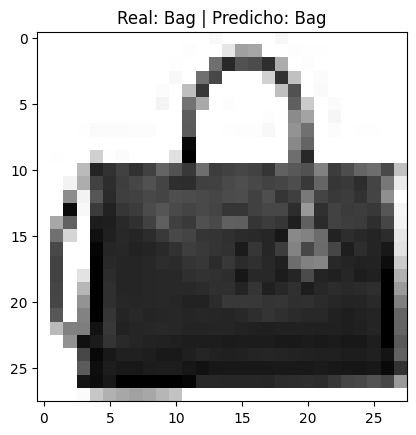

In [ ]:
# Evaluamos la precisión final
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nPrecisión en el set de prueba: {test_acc:.2%}')

# Realizamos una predicción
predictions = model.predict(test_images)

# 1. Elegí qué imagen querés ver (cambiá el número para ver otra prenda)
n = 30

# 2. Mostramos la imagen en blanco y negro (formato binario como el cerebro la procesa)
plt.imshow(test_images[n], cmap=plt.cm.binary)

# 3. Armamos el título con la Realidad vs. la Predicción de la IA
# np.argmax busca el índice con la probabilidad más alta en el vector de salida
titulo = f"Real: {class_names[test_labels[n]]} | Predicho: {class_names[np.argmax(predictions[n])]}"
plt.title(titulo)

# 4. Mostramos el resultado
plt.show()
# Buscamos el índice con la probabilidad más alta
# np.argmax(predictions[n]) nos da la categoría que la red cree más probable

### Accuracy (87.76%):
Es una excelente capacidad de generalización. Significa que tu modelo no solo memorizó los datos de entrenamiento, sino que aprendió las "reglas" para identificar ropa en la vida real.
### Loss (0.3436):
  Este error bajo indica que la red está muy segura de sus predicciones.

## Guía:
- **Normalización:** Si olvidas este paso, notarás que el error (loss) baja muy lentamente o el modelo no converge.
- **Activaciones:** ¿Qué sucede si usas una función lineal en lugar de ReLU en las capas ocultas? La red perdería su capacidad de detectar patrones complejos.
- **Softmax:** Observa cómo las 10 salidas de la última capa compiten entre sí; la prenda con el valor más alto es la elegida por el sistema .

### ¿Por qué ReLU?
Porque es computacionalmente barata y permite entrenar redes de muchas capas sin que la señal se pierda.
### ¿Por qué no linealidad?
Sin funciones como ReLU o Softmax, la red profunda sería solo una gran calculadora de promedios lineales y no podría distinguir una remera de un pantalón.